In [1]:
import pandas as pd

In [6]:
from sklearn.datasets import fetch_california_housing

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = fetch_california_housing()

In [12]:
dataset = pd.DataFrame(df.data)

In [ ]:
dataset.columns=df.feature_names

In [13]:
dataset.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
#Independent feature and dependent features
x = dataset
y = df.target

In [15]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [16]:
# train test slipt
from sklearn.model_selection import train_test_split

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=30, random_state=42)

In [21]:
#standardizing the dataset 
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
scalar.fit_transform(x_train)

array([[-1.1844141 ,  0.7438093 , -0.64602152, ..., -0.02352827,
         0.99155391, -1.29788657],
       [-1.38942356,  1.45886822, -0.02507943, ...,  0.01282462,
        -0.74989936,  0.6286472 ],
       [-0.23250928, -1.87807339, -0.46361466, ..., -0.09399266,
        -1.34910909,  1.16767737],
       ...,
       [-0.49255978,  0.58490732, -0.58276466, ...,  0.02513896,
        -0.74989936,  0.59371006],
       [ 0.97281586, -1.08356348,  0.39016695, ...,  0.01040087,
         0.91197137, -1.19307515],
       [-0.68141475,  1.85612317, -0.81871981, ..., -0.09256876,
         1.00091656, -1.42266208]], shape=(20610, 8))

In [22]:
x_train = scalar.fit_transform(x_train)

In [23]:
x_test = scalar.transform(x_test)

In [24]:
#use linear regression
from sklearn.linear_model import LinearRegression

In [25]:
#cross validation
from sklearn.model_selection import cross_val_score

In [32]:
regression = LinearRegression()
regression.fit(x_train,y_train)
mse = cross_val_score(regression, x_train, y_train, scoring='neg_mean_squared_error',cv=5)

In [30]:
np.mean(mse)

np.float64(-0.5303884503132199)

In [33]:
#prediction
reg_pred = regression.predict(x_test)

In [34]:
reg_pred

array([0.73686304, 1.76121439, 2.67014019, 2.84403584, 2.61691134,
       2.02072237, 2.64542352, 2.17010974, 2.72134884, 3.89696424,
       0.93867929, 1.89662201, 1.74495085, 2.24638855, 2.55500488,
       1.91690943, 2.39781665, 2.00956795, 2.23324689, 1.14647529,
       2.90155572, 2.64994537, 1.89828217, 3.34637313, 2.24175641,
       0.91492936, 1.83202458, 1.66578014, 1.93170379, 3.2533785 ])

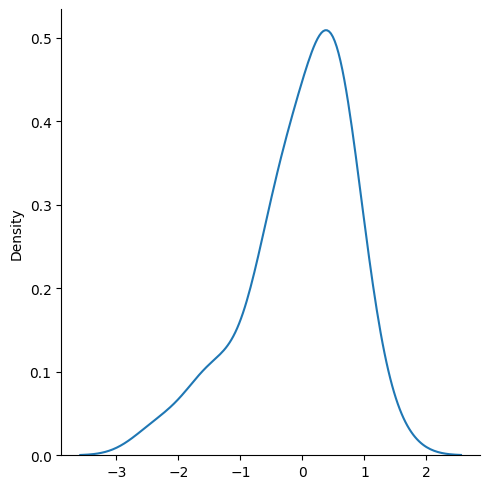

In [36]:
sns.displot(reg_pred-y_test,kind='kde')

In [37]:
from sklearn.metrics import r2_score

In [38]:
score = r2_score(reg_pred,y_test)
score

-0.30315059525452126

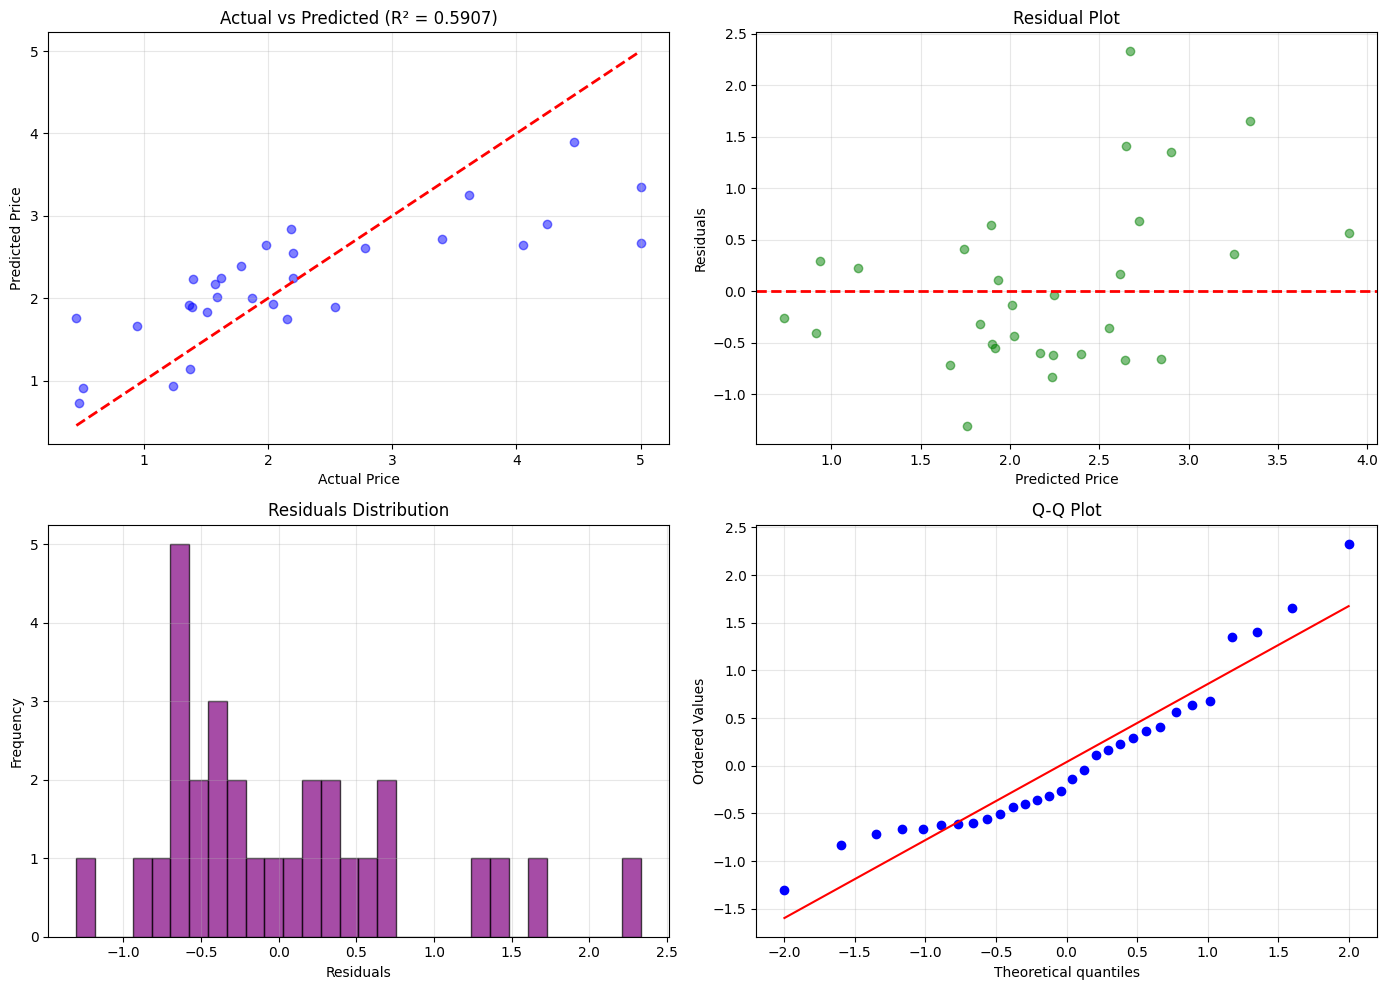

MODEL FIT QUALITY METRICS
R² Score: 0.5907  (1.0 = Perfect fit, 0 = Poor fit)
RMSE: 0.8116  (Lower is better)
MAE: 0.6403  (Lower is better)
Mean Residual: 0.0390  (Should be close to 0)
Std Dev of Residuals: 0.8107
✓ MODERATE FIT - Line fits okay


In [43]:
# Visualize Line Fit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate metrics
mse = mean_squared_error(y_test, reg_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, reg_pred)
r2 = r2_score(y_test, reg_pred)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, reg_pred, alpha=0.5, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2:.4f})')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - reg_pred
axes[0, 1].scatter(reg_pred, residuals, alpha=0.5, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals Distribution
axes[1, 0].hist(residuals, bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residuals Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Q-Q Plot (Normal Probability Plot)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print metrics
print("=" * 50)
print("MODEL FIT QUALITY METRICS")
print("=" * 50)
print(f"R² Score: {r2:.4f}  (1.0 = Perfect fit, 0 = Poor fit)")
print(f"RMSE: {rmse:.4f}  (Lower is better)")
print(f"MAE: {mae:.4f}  (Lower is better)")
print(f"Mean Residual: {np.mean(residuals):.4f}  (Should be close to 0)")
print(f"Std Dev of Residuals: {np.std(residuals):.4f}")
print("=" * 50)

if r2 > 0.8:
    print("✓ EXCELLENT FIT - Line fits very well!")
elif r2 > 0.6:
    print("✓ GOOD FIT - Line fits reasonably well")
elif r2 > 0.4:
    print("✓ MODERATE FIT - Line fits okay")
else:
    print("✗ POOR FIT - Line doesn't fit well")